**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 4**  
**Producto:** Esmeraldas talladas, **HS 710391** (rubíes, zafiros y esmeraldas: el código no aísla la esmeralda, como advierte la ficha). Estructura comercial con el **capítulo 71**.  
**Ficha técnica de referencia:** *Ficha técnica del estudio — Sector esmeraldero* (2026). La serie 2016-2025 por destino se descargó de Trade Map para este cuaderno. Los tres reportes EMIS no se redistribuyen: el cuaderno los pide al ejecutarse.

***

## La pregunta del equipo

> ¿Cómo reducir la vulnerabilidad por concentración de destinos, enfrentar la presión competitiva de otros productores y acceder a segmentos de mayor valor agregado?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Participación por destino** | ¿A quién le vende Colombia sus esmeraldas talladas? |
| **HHI, Theil y número equivalente** | ¿Qué tan concentrados están los destinos y cómo ha cambiado desde 2016? |
| **Crecimiento exportador** | ¿Crecen o caen las exportaciones año a año? |
| **RCA, RSCA y NRCA** | ¿Colombia, Brasil y Etiopía están especializados en HS 710391? |
| **Apertura comercial e IBCR de los mercados** | ¿Qué tan abiertas son la UE, Emiratos, Singapur y Suiza? |
| **Grubel-Lloyd del capítulo 71** | ¿El comercio de piedras y metales preciosos es interindustrial o intraindustrial? |
| **Crecimiento de importaciones y participación de Colombia** | ¿En qué destinos crece la demanda y cuánto de ella es colombiana? |
| **Ficha financiera EMIS** | ¿Cómo les va a las comercializadoras esmeralderas? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [ ]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [ ]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 4/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "exp_2025": "Proyectos finales/Grupo 4/datos/EXPORTACIONES DE COLOMBIA AL MUNDO.csv",
    "brasil_2025": "Proyectos finales/Grupo 4/datos/EXPORTACIONES DE BRAZIL HACIA EL MUNDO.csv",
    "mundo_exp": "Proyectos finales/Grupo 4/datos/EXPORTACIONES DEL MUNDO.csv",
    "cap71_exp": "Proyectos finales/Grupo 4/datos/EXPORTACIONES COLOMBIA HACIA EL MUNDO CAPITULO 71.csv",
    "cap71_imp": "Proyectos finales/Grupo 4/datos/IMPORTACIONES COLOMBIA HACIA EL MUNDO CAPITULO 71.csv",
    "exp_serie": "Proyectos finales/Grupo 4/datos/colombias-exports-to-world-by-importer_710391.csv",
    "wb_pib": "data/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv",
    "wb_exp": "data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140.csv",
    "wb_imp": "data/API_NE.IMP.GNFS.CD_DS2_en_csv_v2_33330.csv",
    "canasta_co_exp": "data/co_exp_productos_hs2_serie.xls",
    "canasta_co_imp": "data/co_imp_productos_hs2_serie.csv",
    "canasta_mundo_exp": "data/mundo_exp_productos_hs2_serie.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  12 archivos


In [ ]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Los 12 archivos ya estaban descargados.
  ok    exp_2025       -> EXPORTACIONES DE COLOMBIA AL MUNDO.csv
  ok    brasil_2025    -> EXPORTACIONES DE BRAZIL HACIA EL MUNDO.csv
  ok    mundo_exp      -> EXPORTACIONES DEL MUNDO.csv
  ok    cap71_exp      -> EXPORTACIONES COLOMBIA HACIA EL MUNDO CAPITULO 71.csv
  ok    cap71_imp      -> IMPORTACIONES COLOMBIA HACIA EL MUNDO CAPITULO 71.csv
  ok    exp_serie      -> colombias-exports-to-world-by-importer_710391.csv
  ok    wb_pib         -> API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv
  ok    wb_exp         -> API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140.csv
  ok    wb_imp         -> API_NE.IMP.GNFS.CD_DS2_en_csv_v2_33330.csv
  ok    canasta_co_exp -> co_exp_productos_hs2_serie.xls
  ok    canasta_co_imp -> co_imp_productos_hs2_serie.csv
  ok    canasta_mundo_exp -> mundo_exp_productos_hs2_serie.csv


In [ ]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [ ]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def theil(valores):
    """Indice de Theil: dispersion por entropia. 0 = reparto perfectamente igual; sin techo superior."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[valores > 0]
    n = len(valores)
    media = valores.mean()
    return float((1 / n) * np.sum((valores / media) * np.log(valores / media)))

def grubel_lloyd(exportaciones, importaciones):
    """Indice de Grubel-Lloyd: 1 = comercio intraindustrial puro, 0 = interindustrial puro."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, 1 - np.abs(exportaciones - importaciones) / comercio_total, np.nan)

def ibcr(exportaciones, importaciones):
    """Indice de Balanza Comercial Relativa: (X - M) / (X + M), entre -1 y +1."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, (exportaciones - importaciones) / comercio_total, np.nan)

def apertura_comercial(exportaciones_totales, importaciones_totales, pib):
    """Indice de Apertura Comercial: (X + M) / PIB x 100, con los flujos TOTALES de la economia."""
    pib = np.asarray(pib, dtype=float)
    return np.where(pib > 0, (np.asarray(exportaciones_totales, dtype=float) + np.asarray(importaciones_totales, dtype=float)) / pib * 100, np.nan)

def rca_balassa(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """Ventaja Comparativa Revelada de Balassa (1965). Mayor que 1 = especializacion revelada."""
    participacion_pais  = np.asarray(x_pais, dtype=float)  / np.asarray(x_pais_total, dtype=float)
    participacion_mundo = np.asarray(x_mundo, dtype=float) / np.asarray(x_mundo_total, dtype=float)
    return participacion_pais / participacion_mundo


def rsca_laursen(rca):
    """RCA simetrico de Laursen: (RCA - 1) / (RCA + 1), entre -1 y +1, con 0 como punto neutro."""
    rca = np.asarray(rca, dtype=float)
    return (rca - 1) / (rca + 1)

def nrca(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """NRCA de Yu, Cai y Leung (2009): distancia entre la exportacion observada y la neutral. Suma cero."""
    x_pais, x_mundo = np.asarray(x_pais, dtype=float), np.asarray(x_mundo, dtype=float)
    x_pais_total, x_mundo_total = float(x_pais_total), float(x_mundo_total)
    observado = x_pais / x_mundo_total
    neutral   = (x_pais_total * x_mundo) / (x_mundo_total ** 2)
    return observado - neutral

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos

Cinco CSV de Trade Map del equipo (cortes de 2025), la serie 2016-2025 por destino, tres archivos del Banco Mundial (PIB, exportaciones e importaciones totales) y la canasta HS2 del curso.

Dos trampas de los archivos del equipo: en `EXPORTACIONES DE COLOMBIA AL MUNDO.csv` la cantidad viene en cero para todos los destinos (el valor unitario no es calculable), y en el archivo de importaciones del capítulo 71 la columna `Balance` repite el balance de las exportaciones, así que solo se usa `Value`.

In [ ]:
exp_2025   = leer_trademap(ruta("exp_2025"))       # Colombia exporta 710391 por destino, 2025
brasil     = leer_trademap(ruta("brasil_2025"))    # Brasil exporta 710391 por destino, 2025
mundo_exp  = leer_trademap(ruta("mundo_exp"))      # exportadores mundiales de 710391, 2025
cap71_exp  = leer_trademap(ruta("cap71_exp"))      # Colombia exporta capitulo 71 por destino, 2025
cap71_imp  = leer_trademap(ruta("cap71_imp"))      # Colombia importa capitulo 71 por origen, 2025
serie      = leer_serie_trademap(ruta("exp_serie"))
wb_pib = leer_banco_mundial(ruta("wb_pib"), "pib_usd")
wb_exp = leer_banco_mundial(ruta("wb_exp"), "exportaciones_usd")
wb_imp = leer_banco_mundial(ruta("wb_imp"), "importaciones_usd")
canasta_co_exp, canasta_co_imp, canasta_mundo_exp = (leer_canasta(ruta(k)) for k in ("canasta_co_exp", "canasta_co_imp", "canasta_mundo_exp"))

mundo_2025, destinos_2025 = separar_mundo(exp_2025)
mundo_oferta, exportadores = separar_mundo(mundo_exp)
print(f"Colombia exporto HS 710391 por USD {mundo_2025['valor_kusd']:,.0f} miles en 2025 a {len(destinos_2025)} destinos (se excluye la fila 'Zona franca')")
print(f"El mundo exporto HS 710391 por USD {mundo_oferta['valor_kusd']:,.0f} miles; Colombia es el exportador n.º {int(exportadores.reset_index().index[exportadores['pais'] == 'Colombia'][0]) + 1}")
destinos_2025[["pais", "valor_kusd", "participacion_pct", "cuota_en_socio_pct", "ranking_socio", "crec_valor_5a_pct", "crec_importaciones_socio_5a_pct"]].head(10)

/tmp/ipykernel_766/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_766/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_766/853157627.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

Colombia exporto HS 710391 por USD 121,111 miles en 2025 a 27 destinos (se excluye la fila 'Zona franca')
El mundo exporto HS 710391 por USD 7,889,069 miles; Colombia es el exportador n.º 11


,pais,valor_kusd,participacion_pct,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_importaciones_socio_5a_pct
0,"Hong Kong, China","67,404.0000",55.6547,1.0608,1.0000,33.0000,7.0000
1,Tailandia,"17,714.0000",14.6263,7.9728,4.0000,41.0000,31.0000
2,Estados Unidos de América,"16,083.0000",13.2796,11.5197,3.0000,-21.0000,1.0000
3,Francia,"7,649.0000",6.3157,10.0627,5.0000,127.0000,13.0000
4,Japón,"7,500.0000",6.1927,27.3598,12.0000,3.0000,9.0000
5,Italia,"1,083.0000",0.8942,22.1649,7.0000,-28.0000,-5.0000
6,Alemania,700.0000,0.5780,5.4848,13.0000,-14.0000,2.0000
7,Emiratos Árabes Unidos,386.0000,0.3187,0.1381,6.0000,12.0000,17.0000
8,India,363.0000,0.2997,0.0679,8.0000,-29.0000,20.0000
9,Singapur,327.0000,0.2700,5.6045,10.0000,-9.0000,-11.0000


***
# 2. Participación por destino

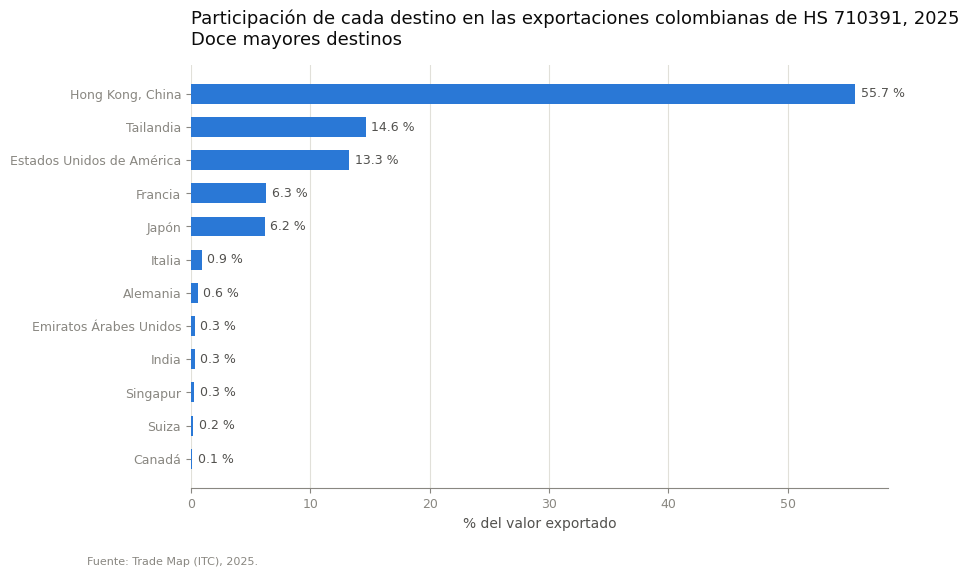

Figura guardada en salidas/g4_participacion_2025.png


,pais,valor_kusd,participacion_pct
0,"Hong Kong, China","67,404.0000",55.6547
1,Tailandia,"17,714.0000",14.6263
2,Estados Unidos de América,"16,083.0000",13.2796
3,Francia,"7,649.0000",6.3157
4,Japón,"7,500.0000",6.1927
5,Italia,"1,083.0000",0.8942
6,Alemania,700.0000,0.5780
7,Emiratos Árabes Unidos,386.0000,0.3187
8,India,363.0000,0.2997
9,Singapur,327.0000,0.2700


In [ ]:
participacion = destinos_2025.nlargest(12, "valor_kusd")[["pais", "valor_kusd", "participacion_pct"]]
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = participacion.sort_values("participacion_pct")
ax.barh(orden["pais"], orden["participacion_pct"], color=AZUL, height=0.6)
for y, v in enumerate(orden["participacion_pct"]):
    ax.annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Participación de cada destino en las exportaciones colombianas de HS 710391, 2025", "Doce mayores destinos",
       "Trade Map (ITC), 2025.", eje_x="% del valor exportado", rejilla="x")
guardar(fig, "g4_participacion_2025")
exportar(participacion, "g4_participacion_2025")

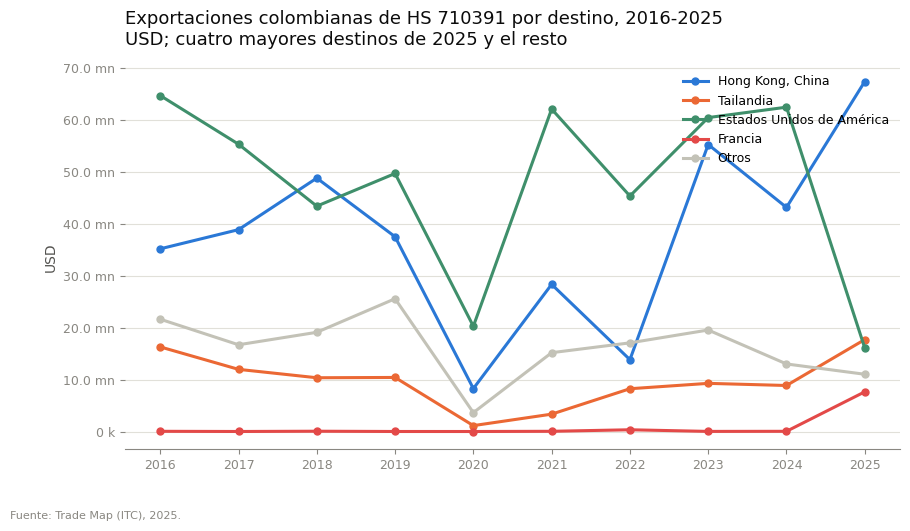

Figura guardada en salidas/g4_series_destinos.png


In [ ]:
paises_serie = serie[serie["codigo"] != "000"]
paises_serie = paises_serie[~paises_serie["pais"].isin(AGREGADOS_NO_PAIS)]
top4 = paises_serie[paises_serie["anio"] == 2025].nlargest(4, "valor_kusd")["pais"].tolist()
series_top = (paises_serie.assign(grupo=lambda d: np.where(d["pais"].isin(top4), d["pais"], "Otros"))
                          .groupby(["anio", "grupo"])["valor_kusd"].sum().unstack("grupo")[top4 + ["Otros"]])
exportar(series_top.reset_index(), "g4_series_destinos")
fig, ax = plt.subplots(figsize=(10, 5))
for color, columna in zip(CATEGORIAS + [GRIS_MID], series_top.columns):
    ax.plot(series_top.index, series_top[columna], color=color, linewidth=2.2, marker="o", markersize=5, label=columna)
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
ax.set_xticks(series_top.index)
ax.legend(frameon=False, fontsize=9, loc="upper right")
estilo(ax, "Exportaciones colombianas de HS 710391 por destino, 2016-2025", "USD; cuatro mayores destinos de 2025 y el resto", "Trade Map (ITC), 2025.", eje_y="USD")
guardar(fig, "g4_series_destinos")

**Análisis del equipo:**

En 2025 Colombia exportó USD 121.1 millones de esmeraldas talladas (HS 710391) a 27 destinos, pero la gráfica muestra que ese valor está lejos de repartirse parejo: Hong Kong concentra el 55.7% (USD 67.4 millones) por sí solo, seguido de lejos por Tailandia (14.6%) y Estados Unidos (13.3%). Los diez destinos restantes del top 10 apenas suman participaciones de un dígito o menos. Para el caso, esto significa que más de la mitad de la demanda depende de un único mercado, que probablemente funciona como centro regional de recorte, pulido y reexportación hacia otros países asiáticos, más que como consumidor final de joyería terminada. La decisión que esto habilita es tratar a Hong Kong como un canal de alto volumen pero de alto riesgo, y usar la brecha frente a mercados con participación baja (Tailandia, Francia, Japón) como el mapa de dónde construir presencia comercial directa.


***
# 3. Concentración: HHI, Theil y número equivalente, 2016-2025

In [ ]:
concentracion = (paises_serie.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, Theil=theil, CR3=lambda v: cr_n(v, 3), destinos_activos=lambda v: int((v > 0).sum()))
                 .reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
exportar(concentracion, "g4_concentracion")
concentracion

,anio,HHI,Theil,CR3,destinos_activos,numero_equivalente
0,2016,0.3031,1.8170,84.2762,30,3.2991
1,2017,0.3151,1.7479,86.3977,26,3.1734
2,2018,0.2995,1.7370,84.2529,27,3.3390
3,2019,0.2759,1.7019,81.2771,27,3.6243
4,2020,0.4371,1.8670,91.9002,21,2.2878
5,2021,0.3982,2.0630,89.3009,29,2.5115
6,2022,0.3288,1.8350,79.4732,32,3.0417
7,2023,0.3325,1.9416,87.8209,27,3.0078
8,2024,0.3626,1.7546,89.7623,21,2.7580
9,2025,0.3641,1.8294,84.4200,25,2.7464


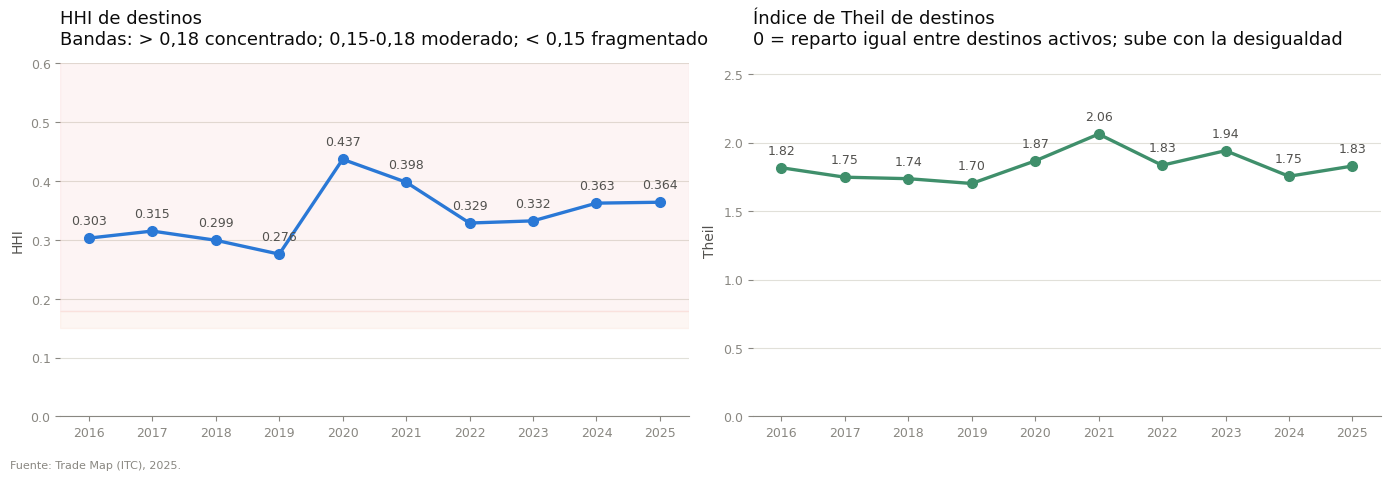

Figura guardada en salidas/g4_concentracion.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(concentracion["anio"], concentracion["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, f in concentracion.iterrows():
    axes[0].annotate(f"{f['HHI']:.3f}", (f["anio"], f["HHI"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhspan(0.18, 1, color=ROJO, alpha=0.06)
axes[0].axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
axes[0].set_ylim(0, max(0.6, concentracion["HHI"].max() * 1.2))
axes[0].set_xticks(concentracion["anio"])
estilo(axes[0], "HHI de destinos", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", eje_y="HHI")
axes[1].plot(concentracion["anio"], concentracion["Theil"], color=VERDE, linewidth=2.4, marker="o", markersize=7)
for _, f in concentracion.iterrows():
    axes[1].annotate(f"{f['Theil']:.2f}", (f["anio"], f["Theil"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].set_ylim(0, concentracion["Theil"].max() * 1.25)
axes[1].set_xticks(concentracion["anio"])
estilo(axes[1], "Índice de Theil de destinos", "0 = reparto igual entre destinos activos; sube con la desigualdad", "Trade Map (ITC), 2025.", eje_y="Theil")
plt.tight_layout()
guardar(fig, "g4_concentracion")

**Análisis del equipo:** HHI y Theil no siempre cuentan la misma historia. ¿Coinciden aquí?

Sí coinciden: el HHI subió de 0.276 en 2019 a 0.364 en 2025 (zona de alta concentración, por encima del umbral de 0.18 que marca el propio gráfico), y el Theil se mueve en la misma dirección (1.70 a 1.83 en el mismo periodo). El número de destinos "equivalentes" cayó a 2.75 y el CR3 llegó a 84.4%: aunque Colombia le vende a 25 países, el peso comercial real equivale a depender de menos de tres. Para el caso, esto significa que la concentración no es un fenómeno puntual de 2025 sino una tendencia que se ha profundizado en los últimos años, no que se haya corregido con la recuperación pospandemia. La decisión que esto habilita es fijar la diversificación de destinos como objetivo estratégico explícito, con una meta concreta (por ejemplo, bajar el HHI por debajo de 0.25 en el mediano plazo), y no solo como una intención genérica.


***
# 4. Crecimiento exportador

CAGR 2016-2025: -1.4 %   |   2020-2025: +29.4 %
Trade Map reporta para 2025: crecimiento 5 años +6 %, 2 años -5 %


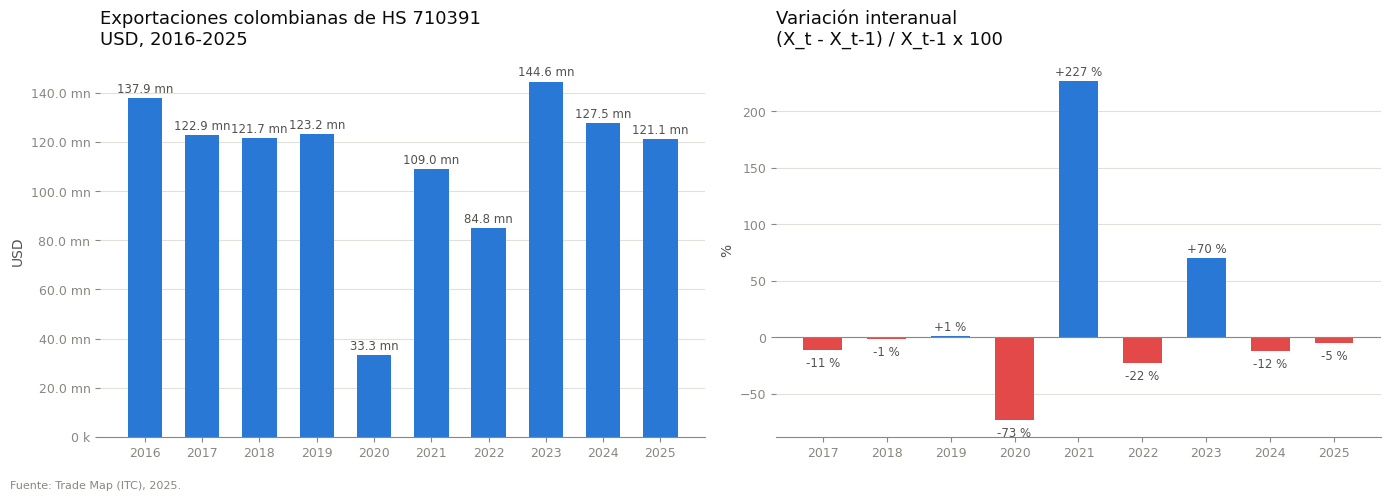

Figura guardada en salidas/g4_crecimiento.png


,valor_kusd,variacion_interanual_pct
anio,,
2016,137853,NaN
2017,122897,-10.8492
2018,121732,-0.9479
2019,123199,1.2051
2020,33332,-72.9446
2021,109020,227.0731
2022,84849,-22.1712
2023,144574,70.3898
2024,127536,-11.7850


In [ ]:
total = serie[serie["codigo"] == "000"].set_index("anio")["valor_kusd"]
crecimiento = pd.DataFrame({"valor_kusd": total})
crecimiento["variacion_interanual_pct"] = crecimiento["valor_kusd"].pct_change() * 100
print(f"CAGR 2016-2025: {cagr(total[2016], total[2025], 9):+.1f} %   |   2020-2025: {cagr(total[2020], total[2025], 5):+.1f} %")
print(f"Trade Map reporta para 2025: crecimiento 5 años {mundo_2025['crec_valor_5a_pct']:+.0f} %, 2 años {mundo_2025['crec_valor_2a_pct']:+.0f} %")
exportar(crecimiento.reset_index(), "g4_crecimiento")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(total.index.astype(str), total.values, color=AZUL, width=0.6)
for x, v in enumerate(total.values):
    axes[0].annotate(fmt_miles(v), (x, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, color=GRIS_TEXT)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
estilo(axes[0], "Exportaciones colombianas de HS 710391", "USD, 2016-2025", eje_y="USD")
var = crecimiento["variacion_interanual_pct"].dropna()
axes[1].bar(var.index.astype(str), var.values, color=[ROJO if v < 0 else AZUL for v in var.values], width=0.6)
for x, v in enumerate(var.values):
    axes[1].annotate(f"{v:+.0f} %", (x, v), textcoords="offset points", xytext=(0, 4 if v >= 0 else -12), ha="center", fontsize=8.5, color=GRIS_TEXT)
axes[1].axhline(0, color=GRIS_EJE, linewidth=0.8)
estilo(axes[1], "Variación interanual", "(X_t - X_t-1) / X_t-1 x 100", "Trade Map (ITC), 2025.", eje_y="%")
plt.tight_layout()
guardar(fig, "g4_crecimiento")
crecimiento

**Análisis del equipo:**

El CAGR de largo plazo (2016-2025) es negativo (-1.4%), mientras que el de los últimos cinco años (2020-2025) es fuertemente positivo (+29.4%). La diferencia se explica por la base de comparación: 2020 fue un año atípico por la pandemia (-72.9% frente a 2019), seguido de un rebote de +227% en 2021 y luego un patrón errático (-22.2% en 2022, +70.4% en 2023, -11.8% en 2024, -5.0% en 2025). Para el caso, esto significa que el crecimiento reciente es la recuperación de un choque puntual y no una tendencia sostenida: el valor exportado en 2025 (USD 121.1 millones) sigue por debajo del pico de 2023 (USD 144.6 millones) y apenas iguala los niveles de 2018-2019. La decisión que esto habilita es no usar el CAGR 2020-2025 como evidencia de una expansión sostenible al construir la recomendación final, y en su lugar usar la alta volatilidad como argumento adicional para diversificar destinos y reducir la exposición a choques de demanda concentrados en pocos mercados.


***
# 5. Ventaja comparativa revelada: RCA, RSCA y NRCA

Para comparar países se necesitan sus **exportaciones totales**, que no están en las descargas del equipo. Se usan las exportaciones de bienes y servicios del Banco Mundial (una aproximación: incluyen servicios) para el último año con dato de todos los países. Zambia, nombrado en la ficha, **no aparece en la descarga mundial de HS 710391**, así que no se puede calcular.

Para Colombia se calcula además la serie 2021-2025 del capítulo 71 completo con la canasta del curso.

In [ ]:
COMPARADORES = {"Colombia": "COL", "Brasil": "BRA", "Etiopía": "ETH", "Zambia": "ZMB"}
ANIO_WB = 2024
totales_wb = wb_exp[wb_exp["anio"] == ANIO_WB].set_index("iso3")["exportaciones_usd"] / 1000     # a USD miles
X_w = totales_wb["WLD"]
X_j = mundo_oferta["valor_kusd"]
filas = []
for pais, iso in COMPARADORES.items():
    fila = exportadores[exportadores["pais"] == pais]
    if fila.empty or pd.isna(totales_wb.get(iso)):
        filas.append({"pais": pais, "nota": "sin dato en Trade Map o Banco Mundial"}); continue
    X_ij, X_i = fila.iloc[0]["valor_kusd"], totales_wb[iso]
    r = float(rca_balassa(X_ij, X_i, X_j, X_w))
    filas.append({"pais": pais, "X_ij_710391": X_ij, "X_i_total": X_i, "RCA": r, "RSCA": float(rsca_laursen(r)), "NRCA_x1e4": float(nrca(X_ij, X_i, X_j, X_w)) * 1e4})
vcr = pd.DataFrame(filas)
exportar(vcr, "g4_vcr_comparadores")
vcr

,pais,X_ij_710391,X_i_total,RCA,RSCA,NRCA_x1e4,nota
0,Colombia,"121,111.0000","67,618,959.7641",7.3720,0.7611,0.0322,NaN
1,Brasil,"17,097.0000","392,105,346.0470",0.1795,-0.6957,-0.0241,NaN
2,Etiopía,58.0000,"8,294,520.6328",0.0288,-0.9440,-0.0006,NaN
3,Zambia,NaN,NaN,NaN,NaN,NaN,sin dato en Trade Map o Banco Mundial


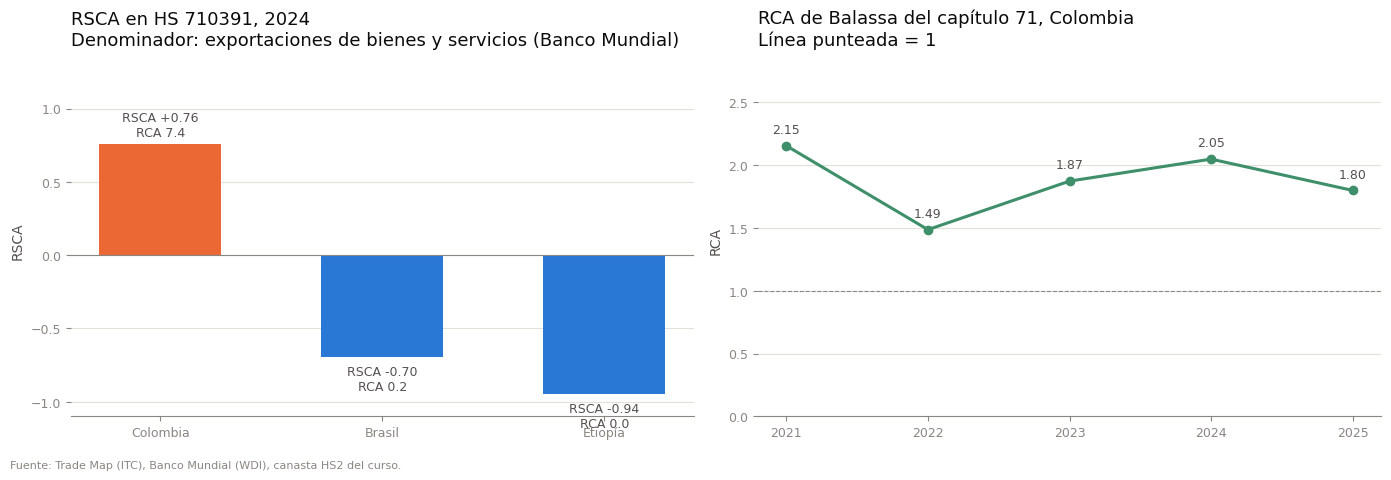

Figura guardada en salidas/g4_vcr.png


In [ ]:
vcr_cap71 = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA]})
vcr_cap71["RCA_cap71"] = rca_balassa(fila_canasta(canasta_co_exp, "71"), fila_canasta(canasta_co_exp, "TOTAL"),
                                     fila_canasta(canasta_mundo_exp, "71"), fila_canasta(canasta_mundo_exp, "TOTAL"))
vcr_cap71["RSCA_cap71"] = rsca_laursen(vcr_cap71["RCA_cap71"])
exportar(vcr_cap71, "g4_vcr_cap71")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
con_dato = vcr.dropna(subset=["RSCA"])
axes[0].bar(con_dato["pais"], con_dato["RSCA"], color=[NARANJA if p == "Colombia" else AZUL for p in con_dato["pais"]], width=0.55)
for x, (v, r) in enumerate(zip(con_dato["RSCA"], con_dato["RCA"])):
    axes[0].annotate(f"RSCA {v:+.2f}\nRCA {r:.1f}", (x, v), textcoords="offset points", xytext=(0, 5 if v >= 0 else -24), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhline(0, color=GRIS_EJE, linewidth=0.8)
axes[0].set_ylim(-1.1, 1.3)
estilo(axes[0], f"RSCA en HS 710391, {ANIO_WB}", "Denominador: exportaciones de bienes y servicios (Banco Mundial)", eje_y="RSCA")
axes[1].plot(vcr_cap71["anio"], vcr_cap71["RCA_cap71"], color=VERDE, linewidth=2.2, marker="o", markersize=6)
for _, f in vcr_cap71.iterrows():
    axes[1].annotate(f"{f['RCA_cap71']:.2f}", (f["anio"], f["RCA_cap71"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].axhline(1, color=GRIS_EJE, linewidth=0.8, linestyle="--")
axes[1].set_xticks(vcr_cap71["anio"])
axes[1].set_ylim(0, vcr_cap71["RCA_cap71"].max() * 1.3)
estilo(axes[1], "RCA de Balassa del capítulo 71, Colombia", "Línea punteada = 1", "Trade Map (ITC), Banco Mundial (WDI), canasta HS2 del curso.", eje_y="RCA")
plt.tight_layout()
guardar(fig, "g4_vcr")

**Análisis del equipo:**

Colombia tiene un RCA de 7.37 y un RSCA de 0.76 en HS 710391, muy por encima de Brasil (RCA 0.18) y Etiopía (RCA 0.03), que no muestran ventaja comparativa revelada en este producto específico (Zambia no se pudo calcular por falta de dato en la descarga mundial). Esto confirma que Colombia sí está especializada internacionalmente en esmeraldas talladas frente a los dos comparadores con dato disponible. Sin embargo, el RCA del capítulo 71 completo (piedras y metales preciosos en general) para Colombia es de apenas 1.80, bastante menor que el RCA del producto específico. Para el caso, esto significa que la ventaja de Colombia está concentrada casi exclusivamente en la esmeralda tallada, no en el sector amplio de piedras preciosas y joyería. La decisión que esto habilita es construir la estrategia de valor agregado sobre el nicho ya ganado (la talla, no la piedra en bruto), sin asumir que existe una base competitiva amplia para expandirse fácilmente a otros productos del capítulo 71.


***
# 6. Apertura comercial e IBCR de los mercados candidatos, 2020-2024

Con los tres archivos del Banco Mundial del curso. La Unión Europea se toma como agregado (`EUU`). Emiratos Árabes Unidos no tiene dato de 2024 en esta versión de los WDI.

In [ ]:
MERCADOS = {"EUU": "Unión Europea", "ARE": "Emiratos Árabes Unidos", "SGP": "Singapur", "CHE": "Suiza", "COL": "Colombia (referencia)"}
macro = (wb_pib.merge(wb_exp, on=["iso3", "pais", "anio"]).merge(wb_imp, on=["iso3", "pais", "anio"]))
macro = macro[macro["iso3"].isin(MERCADOS) & macro["anio"].between(2020, 2024)].copy()
macro["mercado"] = macro["iso3"].map(MERCADOS)
macro["apertura_pct"] = apertura_comercial(macro["exportaciones_usd"], macro["importaciones_usd"], macro["pib_usd"])
macro["IBCR"] = ibcr(macro["exportaciones_usd"], macro["importaciones_usd"])
tabla_macro = macro.pivot(index="anio", columns="mercado", values="apertura_pct")
exportar(macro[["mercado", "iso3", "anio", "pib_usd", "exportaciones_usd", "importaciones_usd", "apertura_pct", "IBCR"]], "g4_apertura_ibcr")
tabla_macro.round(1)

mercado,Colombia (referencia),Emiratos Árabes Unidos,Singapur,Suiza,Unión Europea
anio,,,,,
2020,34.1000,181.3000,331.1000,121.5000,88.1000
2021,40.1000,182.9000,326.5000,128.0000,95.6000
2022,48.3000,185.7000,330.2000,136.2000,108.7000
2023,40.1000,199.0000,323.7000,129.7000,99.9000
2024,36.3000,NaN,313.3000,130.4000,96.5000


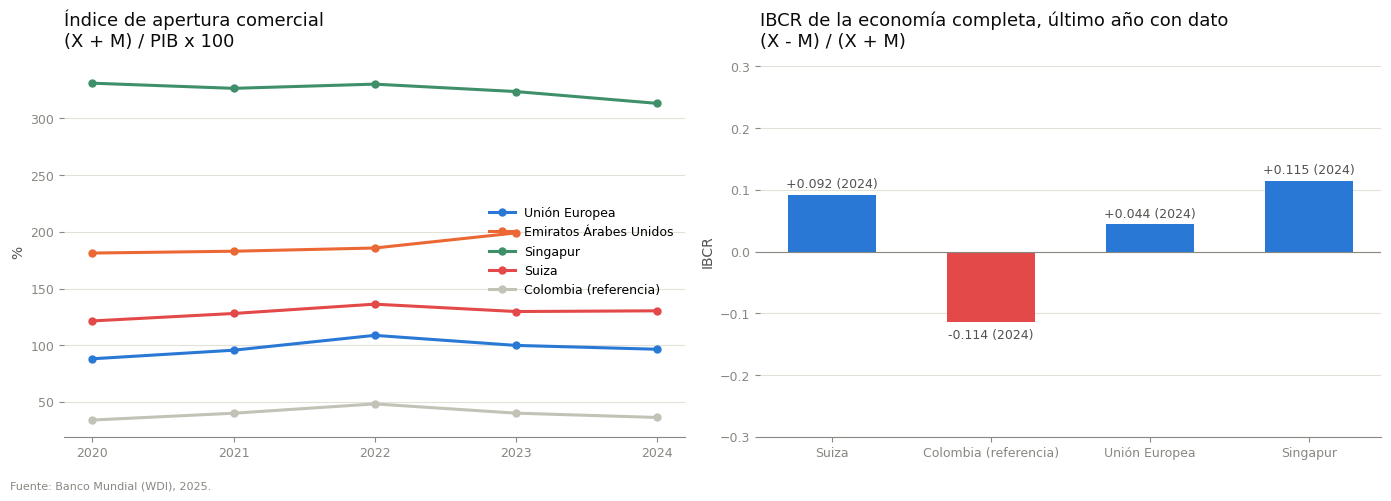

Figura guardada en salidas/g4_apertura_ibcr.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for color, mercado in zip(CATEGORIAS + [GRIS_MID], MERCADOS.values()):
    if mercado in tabla_macro.columns:
        axes[0].plot(tabla_macro.index, tabla_macro[mercado], color=color, linewidth=2.2, marker="o", markersize=5, label=mercado)
axes[0].set_xticks(tabla_macro.index)
axes[0].legend(frameon=False, fontsize=9)
estilo(axes[0], "Índice de apertura comercial", "(X + M) / PIB x 100", eje_y="%")
ultimo = macro.sort_values("anio").groupby("mercado").tail(1).set_index("mercado")
axes[1].bar(ultimo.index, ultimo["IBCR"], color=[ROJO if v < 0 else AZUL for v in ultimo["IBCR"]], width=0.55)
for x, (v, a) in enumerate(zip(ultimo["IBCR"], ultimo["anio"])):
    axes[1].annotate(f"{v:+.3f} ({a})", (x, v), textcoords="offset points", xytext=(0, 5 if v >= 0 else -12), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].axhline(0, color=GRIS_EJE, linewidth=0.8)
axes[1].set_ylim(-0.3, 0.3)
axes[1].tick_params(axis="x", labelsize=8)
estilo(axes[1], "IBCR de la economía completa, último año con dato", "(X - M) / (X + M)", "Banco Mundial (WDI), 2025.", eje_y="IBCR")
plt.tight_layout()
guardar(fig, "g4_apertura_ibcr")

**Análisis del equipo:** ¿Qué dice la apertura de Singapur o Emiratos sobre su papel como hubs de reexportación?

Singapur (313%-331% del PIB) y Emiratos Árabes Unidos (181%-199%, sin dato 2024) tienen índices de apertura comercial varias veces más altos que Suiza (121%-136%) o la Unión Europea (88%-109%), y muy por encima de Colombia (34%-48%). Un índice de apertura muy superior al 100% del PIB —comercio total mayor que toda la economía— es la huella típica de un hub de reexportación, no de un mercado de consumo final. Para el caso, esto significa que entrar a Singapur o Emiratos probablemente no equivale a llegar al consumidor final de joyería, sino a un canal de distribución hacia otros mercados de Asia y Medio Oriente. La decisión que esto habilita es diferenciar la estrategia de entrada: a Suiza y la Unión Europea conviene entrar buscando el consumidor final de lujo, mientras que a Singapur o Emiratos conviene entrar buscando comercializadoras que reexporten, con expectativas de margen y de control de marca distintas en cada caso.


***
# 7. Grubel-Lloyd del capítulo 71

Capitulo 71, 2025 (archivos del equipo): X = 4,854,861  M = 127,775  ->  GL = 0.0513


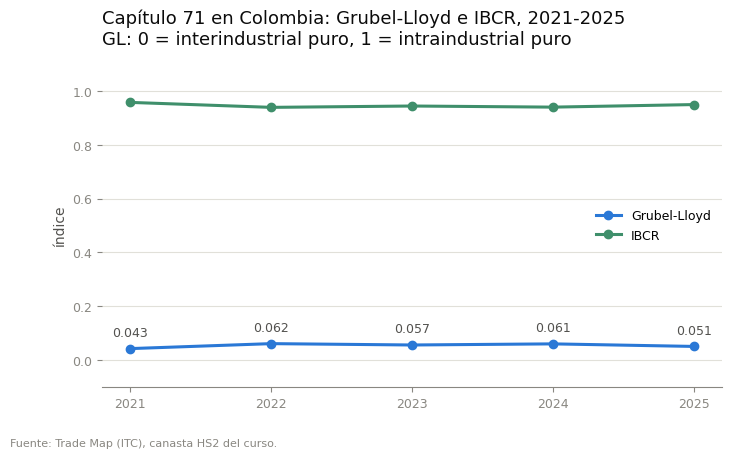

Figura guardada en salidas/g4_grubel_lloyd.png


,anio,X_cap71,M_cap71,GL_cap71,IBCR_cap71
0,2021,"3,345,535.0000","73,874.0000",0.0432,0.9568
1,2022,"3,147,346.0000","100,089.0000",0.0616,0.9384
2,2023,"3,622,309.0000","105,562.0000",0.0566,0.9434
3,2024,"4,325,166.0000","135,540.0000",0.0608,0.9392
4,2025,"4,854,760.0000","127,772.0000",0.0513,0.9487


In [ ]:
X71_2025 = separar_mundo(cap71_exp)[0]["valor_kusd"]
M71_2025 = separar_mundo(cap71_imp)[0]["valor_kusd"]
gl_2025 = float(grubel_lloyd(X71_2025, M71_2025))
print(f"Capitulo 71, 2025 (archivos del equipo): X = {X71_2025:,.0f}  M = {M71_2025:,.0f}  ->  GL = {gl_2025:.4f}")
gl_serie = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA],
                         "X_cap71": fila_canasta(canasta_co_exp, "71").values, "M_cap71": fila_canasta(canasta_co_imp, "71").values})
gl_serie["GL_cap71"] = grubel_lloyd(gl_serie["X_cap71"], gl_serie["M_cap71"])
gl_serie["IBCR_cap71"] = ibcr(gl_serie["X_cap71"], gl_serie["M_cap71"])
exportar(gl_serie, "g4_grubel_lloyd")
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(gl_serie["anio"], gl_serie["GL_cap71"], color=AZUL, linewidth=2.2, marker="o", markersize=6, label="Grubel-Lloyd")
ax.plot(gl_serie["anio"], gl_serie["IBCR_cap71"], color=VERDE, linewidth=2.2, marker="o", markersize=6, label="IBCR")
for _, f in gl_serie.iterrows():
    ax.annotate(f"{f['GL_cap71']:.3f}", (f["anio"], f["GL_cap71"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
ax.set_ylim(-0.1, 1.1)
ax.set_xticks(gl_serie["anio"])
ax.legend(frameon=False, fontsize=9, loc="center right")
estilo(ax, "Capítulo 71 en Colombia: Grubel-Lloyd e IBCR, 2021-2025", "GL: 0 = interindustrial puro, 1 = intraindustrial puro", "Trade Map (ITC), canasta HS2 del curso.", eje_y="índice")
guardar(fig, "g4_grubel_lloyd")
gl_serie

**Análisis del equipo:**

El Grubel-Lloyd del capítulo 71 en 2025 es de solo 0.051 (la escala va de 0 a 1), y se ha mantenido en ese rango bajo desde 2021 (entre 0.043 y 0.062). El IBCR de 0.95 confirma el mismo patrón: Colombia exporta USD 4,854.9 mil del capítulo 71 en 2025 e importa apenas USD 127.8 mil. Para el caso, esto significa que el comercio colombiano del capítulo 71 es casi puramente interindustrial: Colombia es exportador neto de un recurso especializado y prácticamente no participa en un intercambio de ida y vuelta de piedras o metales preciosos. La decisión que esto habilita es que la estrategia de valor agregado no debería apostarle a integrarse en cadenas de intercambio de insumos (importar piedra en bruto de otros países para procesarla y reexportar), sino a fortalecer la posición de Colombia como origen y centro de talla de su propia esmeralda.


***
# 8. Crecimiento de las importaciones y participación de Colombia en cada destino

`cuota_en_socio_pct` = exportaciones de Colombia al destino / importaciones totales de HS 710391 del destino. `crec_importaciones_socio_5a_pct` es el crecimiento de esas importaciones totales.

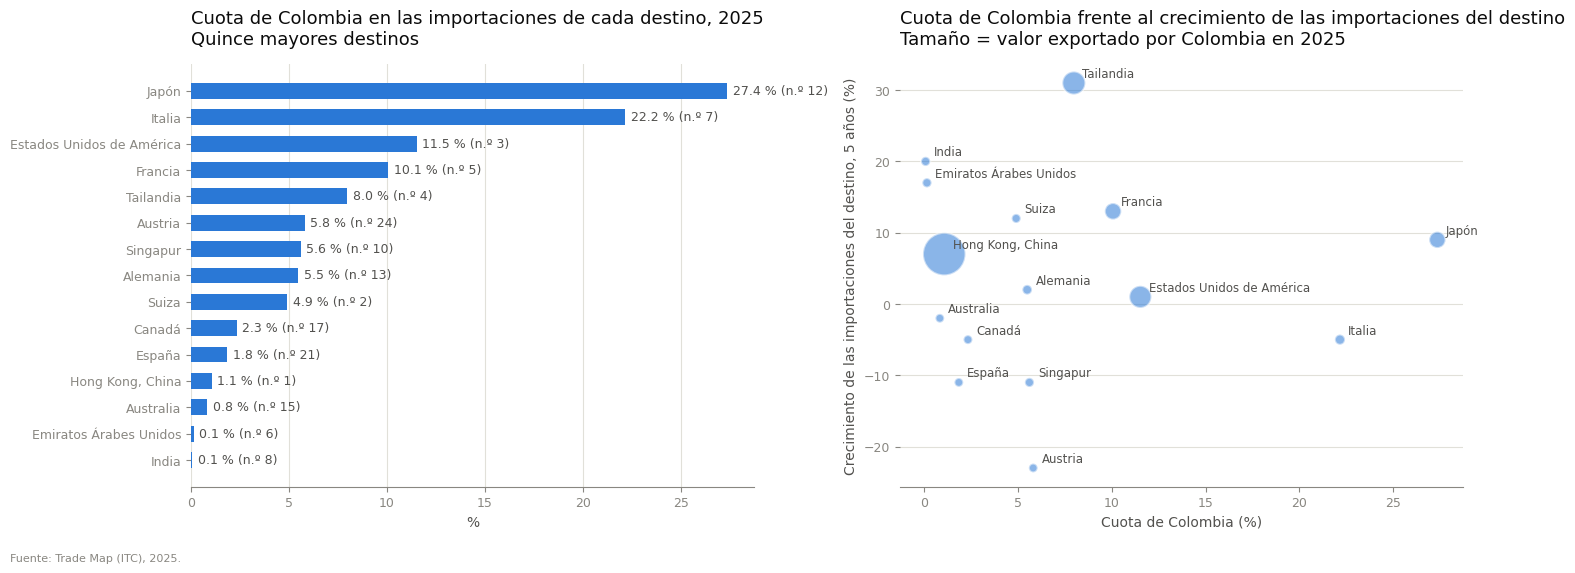

Figura guardada en salidas/g4_mercados.png


,pais,valor_kusd,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_importaciones_socio_5a_pct
0,"Hong Kong, China","67,404.0000",1.0608,1.0000,33.0000,7.0000
1,Tailandia,"17,714.0000",7.9728,4.0000,41.0000,31.0000
2,Estados Unidos de América,"16,083.0000",11.5197,3.0000,-21.0000,1.0000
3,Francia,"7,649.0000",10.0627,5.0000,127.0000,13.0000
4,Japón,"7,500.0000",27.3598,12.0000,3.0000,9.0000
5,Italia,"1,083.0000",22.1649,7.0000,-28.0000,-5.0000
6,Alemania,700.0000,5.4848,13.0000,-14.0000,2.0000
7,Emiratos Árabes Unidos,386.0000,0.1381,6.0000,12.0000,17.0000
8,India,363.0000,0.0679,8.0000,-29.0000,20.0000
9,Singapur,327.0000,5.6045,10.0000,-9.0000,-11.0000


In [ ]:
mercados = destinos_2025.nlargest(15, "valor_kusd")[["pais", "valor_kusd", "cuota_en_socio_pct", "ranking_socio", "crec_valor_5a_pct", "crec_importaciones_socio_5a_pct"]]
exportar(mercados, "g4_mercados")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
orden = mercados.dropna(subset=["cuota_en_socio_pct"]).sort_values("cuota_en_socio_pct")
axes[0].barh(orden["pais"], orden["cuota_en_socio_pct"], color=AZUL, height=0.6)
for y, (v, r) in enumerate(zip(orden["cuota_en_socio_pct"], orden["ranking_socio"])):
    axes[0].annotate(f"{v:.1f} % (n.º {r:.0f})", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(axes[0], "Cuota de Colombia en las importaciones de cada destino, 2025", "Quince mayores destinos", eje_x="%", rejilla="x")
puntos = mercados.dropna(subset=["cuota_en_socio_pct", "crec_importaciones_socio_5a_pct"])
tamanos = puntos["valor_kusd"] / puntos["valor_kusd"].max() * 900 + 40
axes[1].scatter(puntos["cuota_en_socio_pct"], puntos["crec_importaciones_socio_5a_pct"], s=tamanos, color=AZUL, alpha=0.55, edgecolor="white", linewidth=1.5)
for _, p in puntos.iterrows():
    axes[1].annotate(p["pais"], (p["cuota_en_socio_pct"], p["crec_importaciones_socio_5a_pct"]), textcoords="offset points", xytext=(6, 4), fontsize=8.5, color=GRIS_TEXT)
estilo(axes[1], "Cuota de Colombia frente al crecimiento de las importaciones del destino", "Tamaño = valor exportado por Colombia en 2025", "Trade Map (ITC), 2025.",
       eje_x="Cuota de Colombia (%)", eje_y="Crecimiento de las importaciones del destino, 5 años (%)")
plt.tight_layout()
guardar(fig, "g4_mercados")
mercados

**Análisis del equipo:**

Japón tiene la cuota más alta de Colombia entre los mercados grandes (27.4%), pero el crecimiento de sus importaciones totales en 5 años es de apenas +9%: es un mercado donde Colombia ya pesa, pero con poco espacio adicional. Italia, con una cuota similar (22.2%), incluso muestra una caída de -5% en el crecimiento de sus importaciones. En el otro extremo, Tailandia tiene una cuota baja (8.0%) pero el crecimiento de sus importaciones totales de HS 710391 es el más alto de la lista (+31% en 5 años), y Hong Kong —pese a concentrar el 55.7% del valor que exporta Colombia— tiene una cuota de apenas 1.06% en su propio mercado importador, lo que indica que ahí Colombia es un proveedor menor dentro de una demanda enorme. Para el caso, esto significa que "a dónde vendemos más" (Hong Kong) y "dónde tenemos más peso o más espacio de crecimiento" (Japón con peso, Tailandia con crecimiento) son cosas distintas. La decisión que esto habilita es priorizar Tailandia como mercado de expansión (demanda creciente, cuota baja, margen de ganar participación) y tratar a Hong Kong con cautela, dado el bajo peso relativo de Colombia en su demanda total pese a concentrar más de la mitad de las ventas.


***
# 9. Ficha financiera de las comercializadoras (EMIS)

Los tres reportes EMIS (`Esmeraldas de los Andes S A S.xlsx`, `Esmeraldas Mining Services S.A.S.xlsx`, `Esmeraldas Santa Rosa S.A.S.xlsx`) tienen restricción de redistribución y no están en el repositorio. En Colab, esta celda pide subirlos; si no los subes, la sección se salta y el resto del cuaderno funciona igual.

Trampas del formato EMIS: un aviso legal en la primera fila, encabezados reales en la fila 10, varias tablas apiladas en la misma hoja (`Estado de Resultados`, `Balance General`...), cifras en **miles de COP** y un 2021 en ceros que en realidad es dato ausente.

In [ ]:
def leer_emis_anual(ruta_archivo):
    """Extrae el Estado de Resultados de la hoja 'Anual' de un reporte EMIS. Devuelve formato largo en millones de COP."""
    hoja = pd.read_excel(ruta_archivo, sheet_name="Anual", header=None)
    empresa = str(hoja.iloc[2, 1]).strip()
    etiquetas = hoja.iloc[:, 1].astype(str).str.strip()
    inicio = etiquetas.index[etiquetas == "Estado de Resultados"][0]
    fin = etiquetas.index[(etiquetas == "Balance General") & (etiquetas.index > inicio)][0]
    anios = [str(c)[:4] for c in hoja.iloc[inicio, 2:7]]
    bloque = hoja.iloc[inicio + 2:fin, 1:7].copy()
    bloque.columns = ["cuenta"] + anios
    bloque = bloque.dropna(subset=["cuenta"])
    largo = bloque.melt(id_vars="cuenta", var_name="anio", value_name="miles_cop")
    largo["anio"] = largo["anio"].astype(int)
    largo["miles_cop"] = pd.to_numeric(largo["miles_cop"], errors="coerce").replace(0, np.nan)   # 0 = no reportado
    largo["millones_cop"] = largo["miles_cop"] / 1000
    largo.insert(0, "empresa", empresa)
    return largo

base_busqueda = RUTA_BASE if MODO == "local" else "/content"
archivos_emis = sorted(glob.glob(os.path.join(base_busqueda, "**", "Esmeraldas*.xlsx"), recursive=True))
if not archivos_emis and MODO == "github":
    from google.colab import files
    print("Sube los tres reportes EMIS (o cancela para saltar esta seccion).")
    files.upload()
    archivos_emis = sorted(glob.glob(os.path.join("/content", "**", "Esmeraldas*.xlsx"), recursive=True))

if archivos_emis:
    emis = pd.concat([leer_emis_anual(a) for a in archivos_emis], ignore_index=True)
    CUENTAS = ["Total Ingreso Operativo", "Ganancia operativa (EBIT)", "EBITDA", "Ganancia (Pérdida) Neta"]
    resumen_emis = emis[emis["cuenta"].isin(CUENTAS)].pivot_table(index=["empresa", "anio"], columns="cuenta", values="millones_cop")[CUENTAS]
    resumen_emis["margen_EBIT_pct"] = resumen_emis["Ganancia operativa (EBIT)"] / resumen_emis["Total Ingreso Operativo"] * 100
    exportar(resumen_emis.reset_index(), "g4_emis_resumen")
    display(resumen_emis.round(1))
else:
    emis = None
    print("No hay reportes EMIS disponibles: se salta la seccion.")

Sube los tres reportes EMIS (o cancela para saltar esta seccion).


Saving Esmeraldas de los Andes S A S.xlsx to Esmeraldas de los Andes S A S.xlsx
Saving Esmeraldas Mining Services S.A.S.xlsx to Esmeraldas Mining Services S.A.S.xlsx
Saving Esmeraldas Santa Rosa S.A.S.xlsx to Esmeraldas Santa Rosa S.A.S.xlsx


cuenta                                  Total Ingreso Operativo  Ganancia operativa (EBIT)      EBITDA  Ganancia (Pérdida) Neta  margen_EBIT_pct
empresa                           anio                                                                                                          
Esmeraldas Mining Services S.A.S. 2022             101,455.2000                 5,388.1000         NaN              -5,767.0000           5.3000
                                  2023             119,085.8000                 7,865.7000 12,988.7000               5,087.7000           6.6000
                                  2024             121,391.7000                 6,145.5000 11,851.0000               1,410.5000           5.1000
                                  2025             105,427.6000                 4,619.4000  9,521.3000               2,342.6000           4.4000
Esmeraldas Santa Rosa S.A.S       2021              27,130.5000                   569.7000  1,756.8000                -280.3000           2.1000
                                  2022              28,886.3000                 2,810.7000  3,818.8000               1,125.8000           9.7000
                                  2023              34,585.7000                 3,846.2000  4,833.6000                -107.4000          11.1000
                                  2024              38,163.9000                 1,807.1000  2,963.9000                 500.0000           4.7000
                                  2025              41,378.7000                  -670.2000    716.9000              -1,839.8000          -1.6000
Esmeraldas de los Andes S A S     2021              10,855.2000                -5,957.8000 -4,574.5000              -8,995.7000         -54.9000
                                  2022              30,285.7000                13,071.7000 14,517.6000               8,287.4000          43.2000
                                  2023              14,163.3000                -3,609.1000 -2,231.9000               4,298.2000         -25.5000
                                  2024              16,398.2000                -2,903.4000 -1,495.6000              -2,326.6000         -17.7000
                                  2025              13,432.6000                   462.8000  1,863.5000               1,655.8000           3.4000

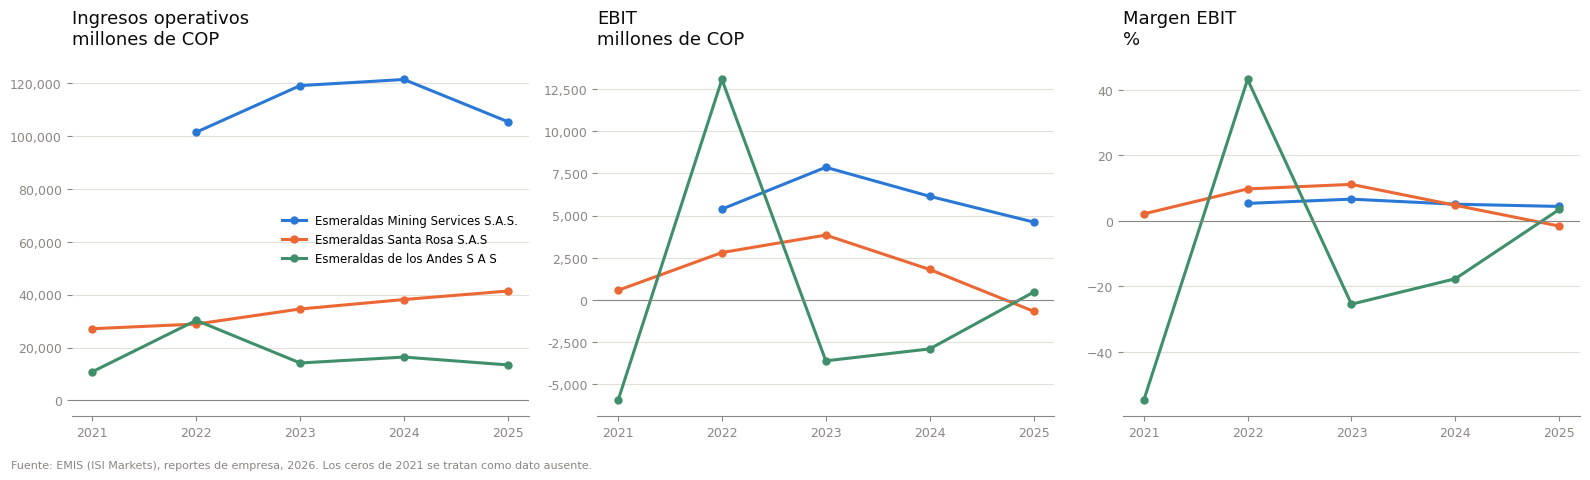

Figura guardada en salidas/g4_emis.png


In [ ]:
if emis is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    empresas = resumen_emis.index.get_level_values("empresa").unique()
    for ax, (cuenta, titulo) in zip(axes, [("Total Ingreso Operativo", "Ingresos operativos"), ("Ganancia operativa (EBIT)", "EBIT"), ("margen_EBIT_pct", "Margen EBIT")]):
        for color, empresa in zip(CATEGORIAS, empresas):
            datos = resumen_emis.loc[empresa, cuenta].dropna()
            ax.plot(datos.index, datos.values, color=color, linewidth=2.2, marker="o", markersize=5, label=empresa)
        ax.set_xticks(range(2021, 2026))
        if cuenta != "margen_EBIT_pct":
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.axhline(0, color=GRIS_EJE, linewidth=0.8)
        estilo(ax, titulo, "millones de COP" if cuenta != "margen_EBIT_pct" else "%", eje_y="")
    axes[0].legend(frameon=False, fontsize=8.5)
    fig.text(0.01, -0.03, "Fuente: EMIS (ISI Markets), reportes de empresa, 2026. Los ceros de 2021 se tratan como dato ausente.", fontsize=8, color=GRIS_EJE)
    plt.tight_layout()
    guardar(fig, "g4_emis")

**Análisis del equipo:** ¿Qué dicen los márgenes sobre la capacidad de las comercializadoras para financiar una estrategia de valor agregado?

Las tres comercializadoras muestran márgenes EBIT bajos y volátiles, ninguna supera el 12% en el periodo. Esmeraldas Mining Services es la más estable, con margen positivo todos los años (4.4%-6.6%) pero en tendencia decreciente. Esmeraldas Santa Rosa tuvo su mejor año en 2023 (11.1%) pero cayó a margen negativo en 2025 (-1.6%). Esmeraldas de los Andes es la más errática, con pérdidas operativas fuertes en 2021, 2023 y 2024, y solo recuperando un margen positivo modesto en 2025 (3.4%). Para el caso, esto significa que ninguna de las tres comercializadoras muestra hoy la solidez financiera para autofinanciar, sin apoyo externo, una estrategia agresiva de valor agregado (canales propios de distribución en mercados nuevos, certificaciones de trazabilidad costosas, etc.). La decisión que esto habilita es que cualquier recomendación de expansión a nuevos mercados debe contemplar alianzas, financiamiento externo o apoyo gremial/estatal (por ejemplo, Procolombia), en lugar de asumir que las comercializadoras pueden financiar la estrategia solo con caja propia.


***
# 10. Tablero de decisión

La ficha cierra con un tablero que reúne todos los indicadores. La tabla siguiente los junta tal como quedaron calculados arriba; el equipo la completa con la columna de **señal** y **decisión** de su cadena interpretativa (DATO → CÁLCULO → INDICADOR → INTERPRETACIÓN → SEÑAL → DECISIÓN).

In [ ]:
ultimo = concentracion.iloc[-1]
tablero = pd.DataFrame([
    {"dimension": "Concentración", "indicador": "HHI destinos 2025", "valor": ultimo["HHI"]},
    {"dimension": "Concentración", "indicador": "Theil destinos 2025", "valor": ultimo["Theil"]},
    {"dimension": "Concentración", "indicador": "Número equivalente de destinos 2025", "valor": ultimo["numero_equivalente"]},
    {"dimension": "Participación", "indicador": f"Participación del mayor destino 2025 ({participacion.iloc[0]['pais']}) %", "valor": participacion.iloc[0]["participacion_pct"]},
    {"dimension": "Desempeño", "indicador": "CAGR exportaciones 2016-2025 %", "valor": cagr(total[2016], total[2025], 9)},
    {"dimension": "Competitividad", "indicador": "RCA Colombia HS 710391", "valor": vcr.set_index("pais").loc["Colombia", "RCA"]},
    {"dimension": "Competitividad", "indicador": "RSCA Colombia HS 710391", "valor": vcr.set_index("pais").loc["Colombia", "RSCA"]},
    {"dimension": "Competitividad", "indicador": "RCA Colombia capítulo 71, 2025", "valor": vcr_cap71.iloc[-1]["RCA_cap71"]},
    {"dimension": "Estructura", "indicador": "Grubel-Lloyd capítulo 71, 2025", "valor": gl_2025},
    {"dimension": "Mercados", "indicador": "Cuota de Colombia en su mayor destino %", "valor": mercados.iloc[0]["cuota_en_socio_pct"]},
])
tablero["senal"] = [
    "Alto (zona roja, > 0.18)",
    "Confirma la misma lectura que el HHI",
    "Bajo: equivale a menos de 3 mercados reales",
    "Dependencia crítica de un solo mercado",
    "Estancamiento de largo plazo",
    "Ventaja comparativa muy fuerte en el producto",
    "Confirma especialización, cercano al máximo",
    "Ventaja moderada en el sector amplio (cap. 71)",
    "Comercio casi puramente interindustrial",
    "Colombia es proveedor menor en su propio mercado top",
]
tablero["decision"] = [
    "Diversificar destinos de forma activa",
    "Refuerza la urgencia de diversificar",
    "Fijar meta de al menos 4-5 destinos relevantes",
    "Tratar a Hong Kong como mercado de riesgo, no de crecimiento",
    "No basar la estrategia solo en el rebote pospandemia",
    "Defender y explotar el nicho de esmeralda tallada",
    "Mismo enfoque: consolidar el nicho actual",
    "No expandir a otros productos del capítulo 71 sin evidencia adicional",
    "No apostar a integrarse en cadenas de insumos importados",
    "Priorizar Tailandia (cuota baja, demanda creciendo 31%)",
]
exportar(tablero, "g4_tablero")
tablero

,dimension,indicador,valor,senal,decision
0,Concentración,HHI destinos 2025,0.3641,,
1,Concentración,Theil destinos 2025,1.8294,,
2,Concentración,Número equivalente de destinos 2025,2.7464,,
3,Participación,Participación del mayor destino 2025 (Hong Kon...,55.6547,,
4,Desempeño,CAGR exportaciones 2016-2025 %,-1.4284,,
5,Competitividad,RCA Colombia HS 710391,7.3720,,
6,Competitividad,RSCA Colombia HS 710391,0.7611,,
7,Competitividad,"RCA Colombia capítulo 71, 2025",1.7985,,
8,Estructura,"Grubel-Lloyd capítulo 71, 2025",0.0513,,
9,Mercados,Cuota de Colombia en su mayor destino %,1.0608,,


**Análisis del equipo:** Complete las columnas de señal y decisión para cada indicador.

El tablero confirma un mismo diagnóstico desde ángulos distintos: alta concentración de destinos (HHI 0.364, CR3 84.4%, solo 2.75 destinos equivalentes), dependencia crítica de Hong Kong (55.7% de las ventas, pero apenas 1.06% de cuota en su mercado, es decir, Colombia es prescindible allí), crecimiento de largo plazo estancado (CAGR -1.4%) y una ventaja comparativa fuerte pero acotada al producto específico (RCA 7.37 en esmeralda tallada frente a 1.80 en todo el capítulo 71, con comercio casi puramente interindustrial, GL 0.051).

**Decisión final del equipo:** recomendamos diversificar hacia Tailandia como mercado prioritario de expansión (cuota baja del 8%, importaciones totales del producto creciendo 31% en 5 años) y reducir gradualmente la dependencia de Hong Kong, complementando con una entrada de mediano plazo a Suiza y la Unión Europea como mercados de consumidor final de lujo (apertura comercial moderada, no son hubs de reexportación como Singapur o Emiratos). Dado que el RCA del capítulo 71 muestra que la ventaja de Colombia está en el producto tallado específico y no en toda la cadena de piedras preciosas, la estrategia debe profundizar el nicho ya ganado en vez de diversificar hacia otros productos del capítulo. Esta decisión se sostiene en la concentración de riesgo (HHI, CR3), el crecimiento inestable de largo plazo (CAGR), la ventaja comparativa específica (RCA/RSCA) y la baja capacidad financiera actual de las comercializadoras (márgenes EBIT volátiles, ninguna por encima del 12%), lo que descarta estrategias que requieran alta inversión inmediata y favorece alianzas o apoyo externo para entrar a Tailandia.


***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School, 33*(2), 99–123.

Yu, R., Cai, J., & Leung, P. (2009). The normalized revealed comparative advantage index. *The Annals of Regional Science, 43*(1), 267–282.

Grubel, H. G., & Lloyd, P. J. (1975). *Intra-industry trade*. Macmillan.

World Bank. (2025). *World Development Indicators*. https://data.worldbank.org

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55


::: {.pie-ean}
**Equipo 4 · Esmeraldas · HS 710391** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
